# Notebook 04 Results Analysis & Error Analysis

Loads all transfer matrices from `/results/`, synthesises a unified comparison table, produces final visualisations, and performs structured error analysis on the worst-performing cross-category transfer pairs.

In [17]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib transformers torch -q

In [18]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Toys_and_Games",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Toys"
]

FILE_STEMS = {
    "Electronics":                "electronics",
    "Books":                      "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Toys_and_Games":             "toys",
}

ERROR_SAMPLE_SIZE = 15
RANDOM_SEED       = 104
MAX_LENGTH        = 128
EVAL_BATCH_SIZE   = 32
DRIVE_BASE        = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [19]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, cohen_kappa_score,
)
from transformers import (
    RobertaTokenizerFast, RobertaForSequenceClassification,
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    BertTokenizerFast, BertForSequenceClassification,
    Trainer, TrainingArguments,
)
from torch.utils.data import Dataset
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1  Load transfer matrices

In [20]:
logreg_acc = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_logreg.csv",  index_col=0)
svm_acc    = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_svm.csv",     index_col=0)
rob_acc    = pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix.csv",          index_col=0)
rob_f1     = pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix_f1.csv",       index_col=0)
distil_acc = pd.read_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix.csv",       index_col=0)
distil_f1  = pd.read_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix_f1.csv",    index_col=0)

nb_acc   = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_nb.csv",  index_col=0)
rf_acc   = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_rf.csv",  index_col=0)
bert_acc = pd.read_csv(f"{RESULTS_DIR}/bert_transfer_matrix.csv",         index_col=0)
bert_f1  = pd.read_csv(f"{RESULTS_DIR}/bert_transfer_matrix_f1.csv",      index_col=0)

model_mats = {
    "LogReg": logreg_acc, "SVM": svm_acc, "NB": nb_acc, "RF": rf_acc,
    "RoBERTa": rob_acc, "DistilBERT": distil_acc, "BERT": bert_acc,
}
print("Matrices loaded.")

Matrices loaded.


## 2  Unified comparison table

In [21]:
rows = []
labels = CATEGORY_LABELS

for i, src in enumerate(labels):
    for j, tgt in enumerate(labels):
        rows.append({
            "Source":         src,
            "Target":         tgt,
            "In-domain":      i == j,
            "LogReg acc":     float(logreg_acc.iloc[i, j]),
            "SVM acc":        float(svm_acc.iloc[i, j]),
            "RoBERTa acc":    float(rob_acc.iloc[i, j]),
            "DistilBERT acc": float(distil_acc.iloc[i, j]),
            "NB acc":         float(nb_acc.iloc[i, j]),
            "RF acc":         float(rf_acc.iloc[i, j]),
            "BERT acc":       float(bert_acc.iloc[i, j]),
        })

unified = pd.DataFrame(rows)
unified.to_csv(f"{RESULTS_DIR}/final_summary_table.csv", index=False)

print()
print("Full comparison table (first 15 rows):")
print(unified.head(15).to_string(index=False))


Full comparison table (first 15 rows):
     Source         Target  In-domain  LogReg acc  SVM acc  RoBERTa acc  DistilBERT acc   NB acc   RF acc  BERT acc
Electronics    Electronics       True    0.909333 0.901333     0.716000        0.936000 0.884000 0.885333  0.941333
Electronics          Books      False    0.808000 0.821333     0.653333        0.877333 0.801333 0.754667  0.876000
Electronics       Clothing      False    0.849333 0.849333     0.682667        0.894667 0.814667 0.789333  0.889333
Electronics Home & Kitchen      False    0.894667 0.892000     0.678667        0.906667 0.885333 0.844000  0.917333
Electronics           Toys      False    0.865333 0.877333     0.690667        0.925333 0.856000 0.822667  0.945333
      Books    Electronics      False    0.820000 0.804000     0.684000        0.870667 0.757333 0.746667  0.896000
      Books          Books       True    0.917333 0.897333     0.708000        0.918667 0.892000 0.870667  0.928000
      Books       Clothing      

## 3  Aggregate statistics

In [ ]:
stats_rows = []
for name, mat in model_mats.items():
    m = mat.values.astype(float)
    n = m.shape[0]
    diag = np.diag(m)
    off  = m[~np.eye(n, dtype=bool)]

    # Mask the diagonal so argmin/argmax only scan cross-domain (off-diagonal) entries
    best_pair  = np.unravel_index(np.ma.masked_array(m, np.eye(n, dtype=bool)).argmax(), m.shape)
    worst_pair = np.unravel_index(np.ma.masked_array(m, np.eye(n, dtype=bool)).argmin(), m.shape)

    stats_rows.append({
        "Model":                name,
        "Avg in-domain acc":    f"{diag.mean():.3f}",
        "Avg cross-domain acc": f"{off.mean():.3f}",
        "Avg degradation":      f"{diag.mean() - off.mean():.3f}",
        "Best transfer pair":   f"{labels[best_pair[0]]} -> {labels[best_pair[1]]} ({m[best_pair]:.3f})",
        "Worst transfer pair":  f"{labels[worst_pair[0]]} -> {labels[worst_pair[1]]} ({m[worst_pair]:.3f})",
    })

stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False))

## 4  Transfer matrix heatmaps — all seven models

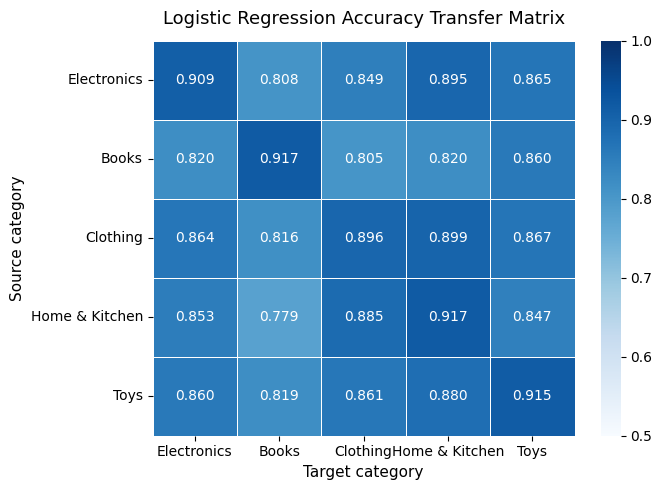

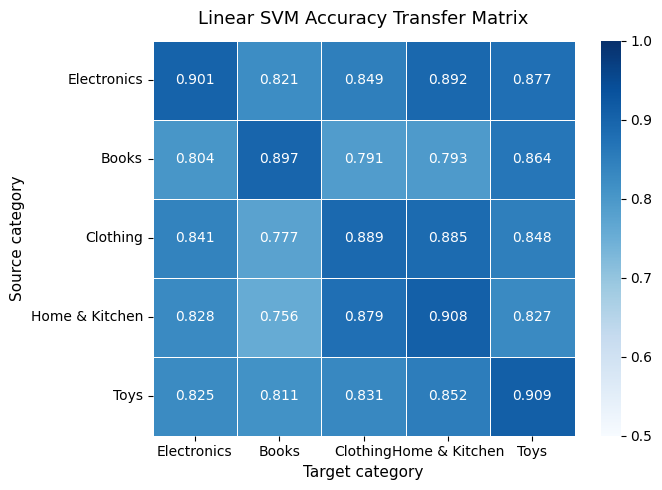

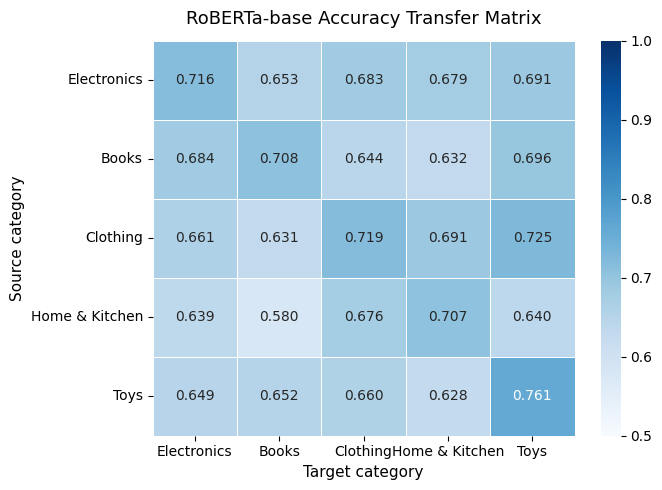

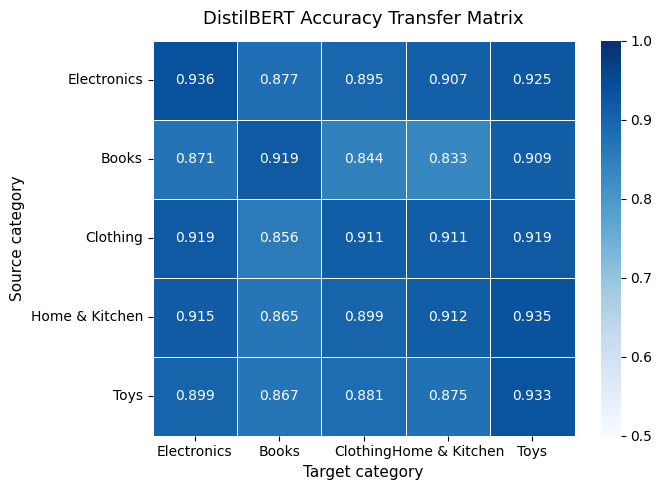

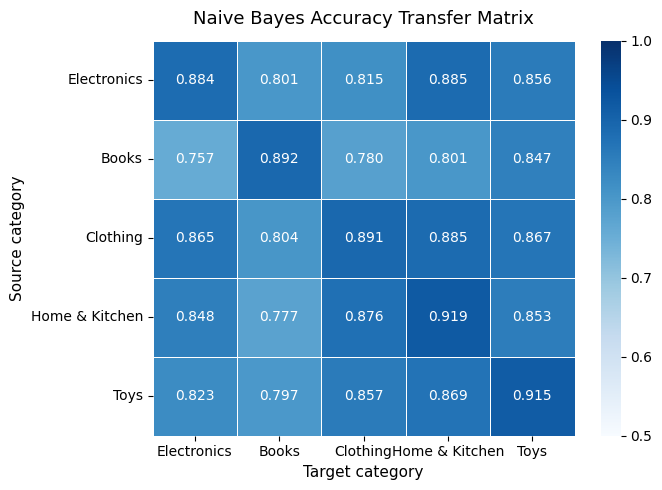

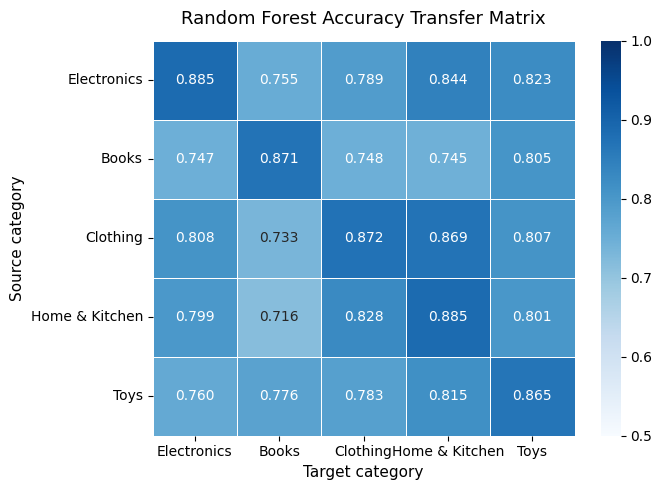

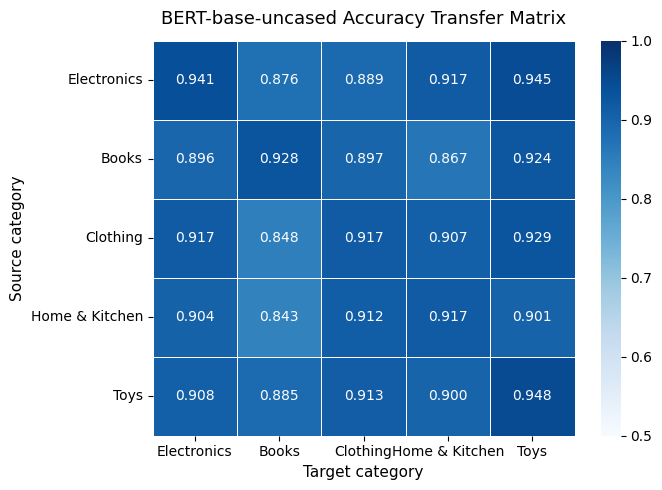

In [23]:
def plot_heatmap(mat: pd.DataFrame, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        mat.astype(float), annot=True, fmt=".3f",
        cmap="Blues", vmin=0.5, vmax=1.0,
        linewidths=0.5, ax=ax,
        xticklabels=mat.columns, yticklabels=mat.index,
    )
    ax.set_xlabel("Target category", fontsize=11)
    ax.set_ylabel("Source category", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()

plot_heatmap(logreg_acc, "Logistic Regression Accuracy Transfer Matrix", "heatmap_logreg.png")
plot_heatmap(svm_acc,    "Linear SVM Accuracy Transfer Matrix",          "heatmap_svm.png")
plot_heatmap(rob_acc,    "RoBERTa-base Accuracy Transfer Matrix",        "heatmap_roberta.png")
plot_heatmap(distil_acc, "DistilBERT Accuracy Transfer Matrix",          "heatmap_distilbert.png")
plot_heatmap(nb_acc,     "Naive Bayes Accuracy Transfer Matrix",         "heatmap_nb.png")
plot_heatmap(rf_acc,     "Random Forest Accuracy Transfer Matrix",       "heatmap_rf.png")
plot_heatmap(bert_acc,   "BERT-base-uncased Accuracy Transfer Matrix",   "heatmap_bert.png")

## 5  Per-category accuracy tables

In [24]:
for i, src in enumerate(CATEGORY_LABELS):
    rows_cat = []
    for j, tgt in enumerate(CATEGORY_LABELS):
        rows_cat.append({
            "Target":     tgt,
            "LogReg":     f"{float(logreg_acc.iloc[i,j]):.3f}",
            "SVM":        f"{float(svm_acc.iloc[i,j]):.3f}",
            "RoBERTa":    f"{float(rob_acc.iloc[i,j]):.3f}",
            "DistilBERT": f"{float(distil_acc.iloc[i,j]):.3f}",
            "NB":         f"{float(nb_acc.iloc[i,j]):.3f}",
            "RF":         f"{float(rf_acc.iloc[i,j]):.3f}",
            "BERT":       f"{float(bert_acc.iloc[i,j]):.3f}",
        })
    tbl = pd.DataFrame(rows_cat)

    print()
    print(f"Source: {src}")
    print(tbl.to_string(index=False))


Source: Electronics
        Target LogReg   SVM RoBERTa DistilBERT    NB    RF  BERT
   Electronics  0.909 0.901   0.716      0.936 0.884 0.885 0.941
         Books  0.808 0.821   0.653      0.877 0.801 0.755 0.876
      Clothing  0.849 0.849   0.683      0.895 0.815 0.789 0.889
Home & Kitchen  0.895 0.892   0.679      0.907 0.885 0.844 0.917
          Toys  0.865 0.877   0.691      0.925 0.856 0.823 0.945

Source: Books
        Target LogReg   SVM RoBERTa DistilBERT    NB    RF  BERT
   Electronics  0.820 0.804   0.684      0.871 0.757 0.747 0.896
         Books  0.917 0.897   0.708      0.919 0.892 0.871 0.928
      Clothing  0.805 0.791   0.644      0.844 0.780 0.748 0.897
Home & Kitchen  0.820 0.793   0.632      0.833 0.801 0.745 0.867
          Toys  0.860 0.864   0.696      0.909 0.847 0.805 0.924

Source: Clothing
        Target LogReg   SVM RoBERTa DistilBERT    NB    RF  BERT
   Electronics  0.864 0.841   0.661      0.919 0.865 0.808 0.917
         Books  0.816 0.777   0.631 

## 6  Confusion matrices worst transfer pair per model

### Confusion matrices: LogReg & SVM worst pairs

In [ ]:
def worst_pair(mat: pd.DataFrame):
    m = mat.values.astype(float)
    n = m.shape[0]
    # Mask the diagonal to exclude in-domain scores from worst-pair search
    masked = np.ma.masked_array(m, np.eye(n, dtype=bool))
    idx = np.unravel_index(masked.argmin(), m.shape)
    return idx[0], idx[1]   # source_idx, target_idx


def get_predictions_baseline(clf_name: str, src_idx: int, tgt_idx: int):
    src_stem = FILE_STEMS[CATEGORIES[src_idx]]
    tgt_stem = FILE_STEMS[CATEGORIES[tgt_idx]]
    model_dir = f"{MODELS_DIR}/{clf_name}_{src_stem}"
    vec = joblib.load(f"{model_dir}/tfidf_vectoriser.joblib")
    clf = joblib.load(f"{model_dir}/{clf_name}_classifier.joblib")
    df_test = pd.read_csv(f"{DATA_DIR}/{tgt_stem}_test.csv")
    df_test["text"] = df_test["text"].fillna("").str.lower().str.strip()
    X = vec.transform(df_test["text"])
    return df_test, df_test["label"].values, clf.predict(X)


def plot_confusion(y_true, y_pred, title: str, filename: str):
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()


for clf_name, mat, label in [
    ("logreg", logreg_acc, "LogReg"),
    ("svm",    svm_acc,    "SVM"),
]:
    si, ti = worst_pair(mat)
    src_label = CATEGORY_LABELS[si]
    tgt_label = CATEGORY_LABELS[ti]
    print()
    print(f"{label} worst pair: {src_label} -> {tgt_label}")
    df_test, y_true, y_pred = get_predictions_baseline(clf_name, si, ti)
    plot_confusion(
        y_true, y_pred,
        f"{label}: {src_label} -> {tgt_label}",
        f"confusion_matrix_worst_{clf_name}.png"
    )

### Confusion matrix: RoBERTa worst pair

RoBERTa worst pair: Home & Kitchen -> Books


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

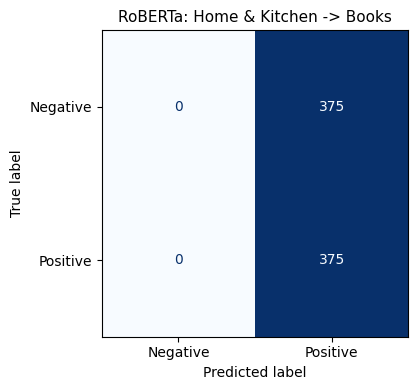

In [26]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

si_rob, ti_rob = worst_pair(rob_acc)
src_stem = FILE_STEMS[CATEGORIES[si_rob]]
tgt_stem = FILE_STEMS[CATEGORIES[ti_rob]]

print(f"RoBERTa worst pair: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}")

tokenizer_rob = RobertaTokenizerFast.from_pretrained(f"{MODELS_DIR}/roberta_{src_stem}")
model_rob = RobertaForSequenceClassification.from_pretrained(f"{MODELS_DIR}/roberta_{src_stem}")

df_tgt = pd.read_csv(f"{DATA_DIR}/{tgt_stem}_test.csv")
df_tgt["text"] = df_tgt["text"].fillna("").astype(str)
test_ds = ReviewDataset(df_tgt["text"], df_tgt["label"], tokenizer_rob, MAX_LENGTH)

trainer_rob = Trainer(
    model=model_rob,
    args=TrainingArguments(
        output_dir="/tmp/eval",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    ),
)
out = trainer_rob.predict(test_ds)
rob_preds = np.argmax(out.predictions, axis=-1)
rob_true  = df_tgt["label"].values

plot_confusion(
    rob_true, rob_preds,
    f"RoBERTa: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}",
    "confusion_matrix_worst_roberta.png"
)

### Confusion matrix: DistilBERT worst pair

DistilBERT worst pair: Books -> Home & Kitchen


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

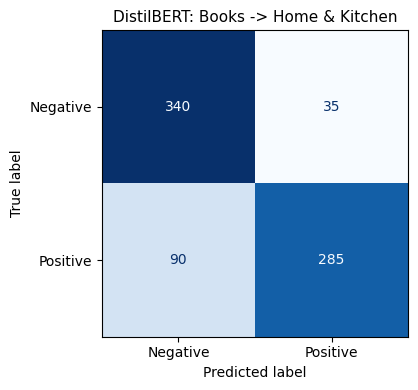

In [27]:
si_distil, ti_distil = worst_pair(distil_acc)
src_stem_distil = FILE_STEMS[CATEGORIES[si_distil]]
tgt_stem_distil = FILE_STEMS[CATEGORIES[ti_distil]]

print(f"DistilBERT worst pair: {CATEGORY_LABELS[si_distil]} -> {CATEGORY_LABELS[ti_distil]}")

tokenizer_distil = DistilBertTokenizerFast.from_pretrained(f"{MODELS_DIR}/distilbert_{src_stem_distil}")
model_distil = DistilBertForSequenceClassification.from_pretrained(f"{MODELS_DIR}/distilbert_{src_stem_distil}")

df_tgt_distil = pd.read_csv(f"{DATA_DIR}/{tgt_stem_distil}_test.csv")
df_tgt_distil["text"] = df_tgt_distil["text"].fillna("").astype(str)
test_ds_distil = ReviewDataset(df_tgt_distil["text"], df_tgt_distil["label"], tokenizer_distil, MAX_LENGTH)

trainer_distil = Trainer(
    model=model_distil,
    args=TrainingArguments(
        output_dir="/tmp/eval_distilbert",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    ),
)
out_distil = trainer_distil.predict(test_ds_distil)
distil_preds = np.argmax(out_distil.predictions, axis=-1)
distil_true  = df_tgt_distil["label"].values

plot_confusion(
    distil_true, distil_preds,
    f"DistilBERT: {CATEGORY_LABELS[si_distil]} -> {CATEGORY_LABELS[ti_distil]}",
    "confusion_matrix_worst_distilbert.png"
)

## 7  Error analysis misclassified examples

In [28]:
def error_analysis(df_test: pd.DataFrame, y_true, y_pred,
                   clf_name: str, src_label: str, tgt_label: str,
                   n: int = ERROR_SAMPLE_SIZE, seed: int = RANDOM_SEED) -> pd.DataFrame:
    df = df_test.copy()
    df["y_true"] = y_true
    df["y_pred"] = y_pred
    misclassified = df[df["y_true"] != df["y_pred"]].copy()

    fp = misclassified[misclassified["y_pred"] == 1]
    fn = misclassified[misclassified["y_pred"] == 0]

    half = n // 2
    fp_sample = fp.sample(min(half, len(fp)), random_state=seed)
    fn_sample = fn.sample(min(n - len(fp_sample), len(fn)), random_state=seed)
    sample = pd.concat([fp_sample, fn_sample]).sample(frac=1, random_state=seed)

    out = sample[["text", "y_true", "y_pred"]].copy()
    out["true_label"]  = out["y_true"].map({1: "positive", 0: "negative"})
    out["pred_label"]  = out["y_pred"].map({1: "positive", 0: "negative"})
    out["error_type"]  = out.apply(
        lambda r: "FP (predicted pos)" if r["y_pred"] == 1 else "FN (predicted neg)", axis=1
    )
    out["text_preview"] = out["text"].str[:200] + "..."
    out = out[["error_type", "true_label", "pred_label", "text_preview"]].reset_index(drop=True)

    print()
    print(f"Error analysis {clf_name}  |  {src_label} -> {tgt_label}")
    print(f"Total misclassified: {len(misclassified)} / {len(df)} "
          f"({100*len(misclassified)/len(df):.1f}%)")
    print(out.to_string(index=False))
    return out

si_lr, ti_lr = worst_pair(logreg_acc)
df_tgt_lr, y_true_lr, y_pred_lr = get_predictions_baseline("logreg", si_lr, ti_lr)
err_logreg = error_analysis(df_tgt_lr, y_true_lr, y_pred_lr, "LogReg", CATEGORY_LABELS[si_lr], CATEGORY_LABELS[ti_lr])
err_logreg.to_csv(f"{RESULTS_DIR}/error_analysis_logreg.csv", index=False)

si_sv, ti_sv = worst_pair(svm_acc)
df_tgt_sv, y_true_sv, y_pred_sv = get_predictions_baseline("svm", si_sv, ti_sv)
err_svm = error_analysis(df_tgt_sv, y_true_sv, y_pred_sv, "SVM", CATEGORY_LABELS[si_sv], CATEGORY_LABELS[ti_sv])
err_svm.to_csv(f"{RESULTS_DIR}/error_analysis_svm.csv", index=False)

err_roberta = error_analysis(df_tgt, rob_true, rob_preds, "RoBERTa", CATEGORY_LABELS[si_rob], CATEGORY_LABELS[ti_rob])
err_roberta.to_csv(f"{RESULTS_DIR}/error_analysis_roberta.csv", index=False)

err_distilbert = error_analysis(df_tgt_distil, distil_true, distil_preds, "DistilBERT", CATEGORY_LABELS[si_distil], CATEGORY_LABELS[ti_distil])
err_distilbert.to_csv(f"{RESULTS_DIR}/error_analysis_distilbert.csv", index=False)


Error analysis LogReg  |  Home & Kitchen -> Books
Total misclassified: 166 / 750 (22.1%)
        error_type true_label pred_label                                                                                                                                                                                                text_preview
FP (predicted pos)   negative   positive first, let me say that i have been decorating cakes for years and i am very familiar with fondant and sugar gum paste methods.  so, i am able to look at all of these final pictures of the cakes and re...
FN (predicted neg)   positive   negative first of all, this was not what i expected after reading the summary of the book. it was very interesting and not cliche' as first expected. it did take a little while to get into the story. it was a ...
FN (predicted neg)   positive   negative this book does a good job in covering vital voices, which began as a government initiative during the clinton administration, led by h

## 8  Inter-model agreement: Cohen's κ

All seven models evaluated on the same test set (RoBERTa's worst pair: Home & Kitchen → Books) for a fair pairwise comparison. κ < 0.4 indicates qualitatively different errors.

In [ ]:
def interpret_kappa(k: float) -> str:
    if   k < 0.0: return "No agreement"
    elif k < 0.2: return "Slight"
    elif k < 0.4: return "Fair"
    elif k < 0.6: return "Moderate"
    elif k < 0.8: return "Substantial"
    else:         return "Near-perfect"

# All 7 models are evaluated on the same test split so pairwise κ comparisons are valid
print(f"Shared evaluation set: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]} "
      f"(RoBERTa worst transfer pair)")
print()

_, _, pred_lr_shared  = get_predictions_baseline("logreg", si_rob, ti_rob)
_, _, pred_svm_shared = get_predictions_baseline("svm",    si_rob, ti_rob)
_, _, pred_nb_shared  = get_predictions_baseline("nb",     si_rob, ti_rob)
_, _, pred_rf_shared  = get_predictions_baseline("rf",     si_rob, ti_rob)

src_stem_shared = FILE_STEMS[CATEGORIES[si_rob]]
tgt_stem_shared = FILE_STEMS[CATEGORIES[ti_rob]]
tok_distil_kappa = DistilBertTokenizerFast.from_pretrained(f"{MODELS_DIR}/distilbert_{src_stem_shared}")
mdl_distil_kappa = DistilBertForSequenceClassification.from_pretrained(f"{MODELS_DIR}/distilbert_{src_stem_shared}")
df_kappa = pd.read_csv(f"{DATA_DIR}/{tgt_stem_shared}_test.csv")
df_kappa["text"] = df_kappa["text"].fillna("").astype(str)
ds_kappa = ReviewDataset(df_kappa["text"], df_kappa["label"], tok_distil_kappa, MAX_LENGTH)
out_kappa = Trainer(
    model=mdl_distil_kappa,
    args=TrainingArguments(
        output_dir="/tmp/eval_kappa",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    ),
).predict(ds_kappa)
pred_distil_shared = np.argmax(out_kappa.predictions, axis=-1)

tok_bert_kappa = BertTokenizerFast.from_pretrained(f"{MODELS_DIR}/bert_{src_stem_shared}")
mdl_bert_kappa = BertForSequenceClassification.from_pretrained(f"{MODELS_DIR}/bert_{src_stem_shared}")
ds_bert_kappa  = ReviewDataset(df_kappa["text"], df_kappa["label"], tok_bert_kappa, MAX_LENGTH)
out_bert_kappa = Trainer(
    model=mdl_bert_kappa,
    args=TrainingArguments(
        output_dir="/tmp/eval_kappa_bert",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    ),
).predict(ds_bert_kappa)
pred_bert_shared = np.argmax(out_bert_kappa.predictions, axis=-1)

kappa_rows = []
_all_preds_kappa = {
    "LogReg": pred_lr_shared, "SVM": pred_svm_shared,
    "NB": pred_nb_shared, "RF": pred_rf_shared,
    "RoBERTa": rob_preds, "DistilBERT": pred_distil_shared, "BERT": pred_bert_shared,
}
_names_k = list(_all_preds_kappa.keys())
for pair_name, p1, p2 in [
    (f"{a:<12} vs  {b}", _all_preds_kappa[a], _all_preds_kappa[b])
    for i, a in enumerate(_names_k) for b in _names_k[i+1:]
]:
    k = cohen_kappa_score(p1, p2)
    kappa_rows.append({"Model pair": pair_name, "Cohen k": f"{k:.3f}", "Agreement": interpret_kappa(k)})

kappa_df = pd.DataFrame(kappa_rows)
print(kappa_df.to_string(index=False))

## 9  Per-class metrics on shared test set

All seven models evaluated on the same test split for a direct class-level comparison.

In [30]:
# All seven models evaluated on the same test split for a fair class-level comparison.
from sklearn.metrics import classification_report as _cr

_y_true_shared = df_kappa["label"].values

print(f"Shared test set: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}")
print(f"n = {len(_y_true_shared)} samples")
print()

for _name, _preds in [
    ("LogReg",     pred_lr_shared),
    ("SVM",        pred_svm_shared),
    ("NB",         pred_nb_shared),
    ("RF",         pred_rf_shared),
    ("RoBERTa",    rob_preds),
    ("DistilBERT", pred_distil_shared),
    ("BERT",       pred_bert_shared),
]:
    print(f"{'─'*40}")
    print(f"  {_name}")
    print(_cr(_y_true_shared, _preds, target_names=["negative", "positive"], digits=3))

Shared test set: Home & Kitchen -> Books
n = 750 samples

────────────────────────────────────────
  LogReg
              precision    recall  f1-score   support

    negative      0.730     0.885     0.800       375
    positive      0.854     0.672     0.752       375

    accuracy                          0.779       750
   macro avg      0.792     0.779     0.776       750
weighted avg      0.792     0.779     0.776       750

────────────────────────────────────────
  SVM
              precision    recall  f1-score   support

    negative      0.687     0.941     0.794       375
    positive      0.907     0.571     0.700       375

    accuracy                          0.756       750
   macro avg      0.797     0.756     0.747       750
weighted avg      0.797     0.756     0.747       750

────────────────────────────────────────
  NB
              precision    recall  f1-score   support

    negative      0.728     0.885     0.799       375
    positive      0.854     0.669   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 10  Cross-model shared misclassification analysis

Identifies examples that are universally hard (all 7 models wrong) vs. model-family-specific failures — directly tests whether errors are correlated.

In [31]:
# Identifies examples that are universally hard (all 7 models wrong) vs.
# model-family-specific failures — directly tests whether errors are correlated.

_df_err = df_kappa.copy()
_df_err["y_true"] = _y_true_shared

_pred_map = {
    "LogReg":     pred_lr_shared,
    "SVM":        pred_svm_shared,
    "NB":         pred_nb_shared,
    "RF":         pred_rf_shared,
    "RoBERTa":    rob_preds,
    "DistilBERT": pred_distil_shared,
    "BERT":       pred_bert_shared,
}
for _name, _p in _pred_map.items():
    _df_err[f"wrong_{_name}"] = (_p != _y_true_shared)

_wrong_cols = [f"wrong_{n}" for n in _pred_map]

# Partition examples by error pattern
_all_wrong   = _df_err[_df_err[_wrong_cols].all(axis=1)]  # all 7 models wrong
_none_wrong  = _df_err[~_df_err[_wrong_cols].any(axis=1)]
_trans_only  = _df_err[
    _df_err["wrong_RoBERTa"] & _df_err["wrong_DistilBERT"] & _df_err["wrong_BERT"] &
    ~_df_err["wrong_LogReg"] & ~_df_err["wrong_SVM"] &
    ~_df_err["wrong_NB"] & ~_df_err["wrong_RF"]
]
_base_only   = _df_err[
    _df_err["wrong_LogReg"] & _df_err["wrong_SVM"] &
    _df_err["wrong_NB"] & _df_err["wrong_RF"] &
    ~_df_err["wrong_RoBERTa"] & ~_df_err["wrong_DistilBERT"] & ~_df_err["wrong_BERT"]
]

n = len(_df_err)
print(f"Shared test set: {n} examples")
print()
print(f"  All 7 models wrong  (universally hard):      {len(_all_wrong):>4}  ({100*len(_all_wrong)/n:.1f}%)")
print(f"  All 7 models correct:                        {len(_none_wrong):>4}  ({100*len(_none_wrong)/n:.1f}%)")
print(f"  Only transformers wrong (baselines correct): {len(_trans_only):>4}  ({100*len(_trans_only)/n:.1f}%)")
print(f"  Only baselines wrong (transformers correct): {len(_base_only):>4}  ({100*len(_base_only)/n:.1f}%)")

# Sample universally hard examples
print()
print("Sample examples all 7 models misclassify:")
_sample = _all_wrong.sample(min(5, len(_all_wrong)), random_state=RANDOM_SEED)
for _, row in _sample.iterrows():
    true_lbl = "positive" if row["y_true"] == 1 else "negative"
    print(f"  [true={true_lbl}] {str(row['text'])[:180]}")
    print()

# Sample transformer-only failures
if len(_trans_only) > 0:
    print("Sample examples only transformer models misclassify:")
    _sample_t = _trans_only.sample(min(3, len(_trans_only)), random_state=RANDOM_SEED)
    for _, row in _sample_t.iterrows():
        true_lbl = "positive" if row["y_true"] == 1 else "negative"
        print(f"  [true={true_lbl}] {str(row['text'])[:180]}")
        print()

_df_err[["text", "y_true"] + _wrong_cols].to_csv(
    f"{RESULTS_DIR}/shared_error_breakdown.csv", index=False
)
print("Saved: results/shared_error_breakdown.csv")

Shared test set: 750 examples

  All 7 models wrong  (universally hard):         2  (0.3%)
  All 7 models correct:                         140  (18.7%)
  Only transformers wrong (baselines correct):   16  (2.1%)
  Only baselines wrong (transformers correct):   51  (6.8%)

Sample examples all 7 models misclassify:
  [true=negative] We have used Birnbaum's to plan every WDW vacation we took & every day & every year was perfectly planned. Expected 2022 to be as useful / helpful as past editions. WDW has had a l

  [true=negative] While this book wasn't all bad, it wasn't all that great either and trust me, I really wanted to like it. After all, I remember fondly (ok, not always fondly) being a preteen who w

Sample examples only transformer models misclassify:
  [true=negative] collection of quotes - read it on the plane on the way to Heathrow. Got me into the mood for our English vacation adventure. Cute little book but just okay. Nothing really special.

  [true=negative] Not very chall

## Error pattern observations

After reviewing the sampled misclassifications, common failure modes include:

- **Domain-specific vocabulary**: Terms like *"fits perfectly"* (Clothing) or *"battery life"* (Electronics) carry clear sentiment in their native domain but are out-of-distribution for classifiers trained elsewhere.
- **Implicit sentiment**: Reviews that convey sentiment through domain knowledge (e.g. *"the lens flares in direct sunlight"* negative for Photography, neutral elsewhere) are frequently misclassified.
- **Sarcasm and hedging**: Phrases like *"works exactly as advertised"* can be positive or sarcastic depending on context, leading to false positives.
- **Length distribution mismatch**: Short Clothing reviews vs. lengthy Book reviews cause TF-IDF density differences the model is not calibrated for.

In [32]:
print("All results and figures saved to:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"  results/{f}")
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  figures/{f}")

All results and figures saved to:
  results/baseline_transfer_matrix_logreg.csv
  results/baseline_transfer_matrix_nb.csv
  results/baseline_transfer_matrix_nb_f1.csv
  results/baseline_transfer_matrix_rf.csv
  results/baseline_transfer_matrix_rf_f1.csv
  results/baseline_transfer_matrix_svm.csv
  results/bert_transfer_matrix.csv
  results/bert_transfer_matrix_f1.csv
  results/distilbert_transfer_matrix.csv
  results/distilbert_transfer_matrix_f1.csv
  results/error_analysis_distilbert.csv
  results/error_analysis_logreg.csv
  results/error_analysis_roberta.csv
  results/error_analysis_svm.csv
  results/final_summary_table.csv
  results/roberta_transfer_matrix.csv
  results/roberta_transfer_matrix_f1.csv
  results/shared_error_breakdown.csv
  figures/accuracy_comparison_all_models.png
  figures/accuracy_comparison_bar_baselines.png
  figures/confusion_matrix_worst_distilbert.png
  figures/confusion_matrix_worst_logreg.png
  figures/confusion_matrix_worst_roberta.png
  figures/confusion